<a href="https://colab.research.google.com/github/Lu2077/Python-Math-s/blob/main/NewtonR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ingrese la función polinómica f(t): e**-t+sin(t)
Ingrese la derivada de la función f(t): -e**-t+cos(t)

Método de Newton-Raphson
  Iteración        t    f'(t)       |f(t)|    Error Absoluto    Error Relativo (%)
-----------  -------  -------  -----------  ----------------  --------------------
          1  3.18305  -1.0406  1.34637e-05       2e-06                 0
          2  3.18306  -1.0406  6.93939e-12       1.29384e-05           0.000406478
          3  3.18306  -1.0406  2.22045e-16       6.66844e-12           2.09498e-10


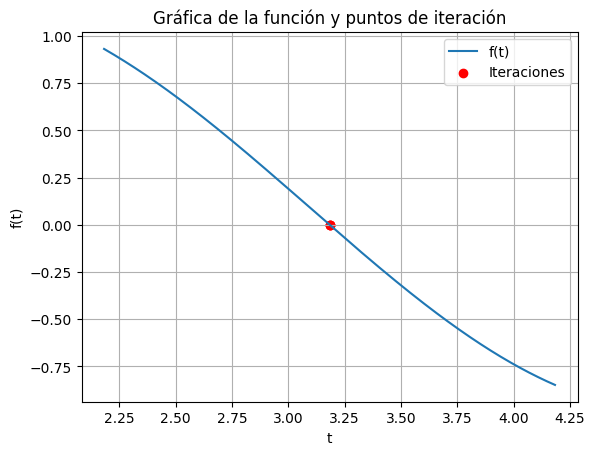


Solución encontrada: t = 3.1830630119333634
Valor de f(t) en la solución: 2.220446049250313e-16


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from sympy import symbols, lambdify, diff, sin, exp

def obtener_funciones():
    t = symbols('t')
    funcion_str = input("Ingrese la función polinómica f(t): ")
    derivada_str = input("Ingrese la derivada de la función f(t): ")

    # Reemplazar 'e' con la constante de Euler de SymPy
    funcion_str = funcion_str.replace('e', 'exp(1)')
    derivada_str = derivada_str.replace('e', 'exp(1)')

    funcion = lambdify(t, funcion_str, 'numpy')
    derivada = lambdify(t, derivada_str, 'numpy')

    return funcion, derivada

def NewtonRaphson(funcion, derivada, t1, es, imax):
    t = t1
    tv = []
    ea = 2 * es
    eav = []
    i = 0
    niter = []
    f_tv = []
    er = 0
    newton_table = []

    while i < imax and ea > es:
        t = t - funcion(t) / derivada(t)
        tv.append(t)
        f_tv.append(funcion(t))
        i += 1
        niter.append(i)

        if i > 1:
            ea = abs(tv[i - 1] - tv[i - 2])
            if tv[i-1] != 0:
                er = abs(ea / tv[i - 1]) * 100
            eav.append(ea)

        newton_table.append([i, t, derivada(t), abs(funcion(t)), ea, er])

    # Tabla de datos
    print("")
    print("Método de Newton-Raphson")
    print(tabulate(newton_table, headers=["Iteración", "t", "f'(t)", "|f(t)|", "Error Absoluto", "Error Relativo (%)"]))

    # Graficar la función y los puntos de iteración
    if len(tv) > 0:
        t_min = min(tv) - 1
        t_max = max(tv) + 1
    else:
        t_min, t_max = -10, 10  # Rango predeterminado si no hay puntos de iteración

    # Limitar el rango al intervalo [-1, 5]
    t_min = max(t_min, -1)
    t_max = min(t_max, 5)

    t_vals = np.linspace(t_min, t_max, 400)
    f_vals = funcion(t_vals)
    plt.plot(t_vals, f_vals, label='f(t)')
    plt.scatter(tv, np.zeros_like(tv), color='red', label='Iteraciones')
    plt.xlabel('t')
    plt.ylabel('f(t)')
    plt.title('Gráfica de la función y puntos de iteración')
    plt.grid(True)
    plt.legend()
    plt.show()

    return t, funcion(t)

# Ejemplo de uso
funcion, derivada = obtener_funciones()
#(valor inicial, tolerancia, iteraciones max)
t_solucion, valor_f_t = NewtonRaphson(funcion, derivada, 3.2, 0.000001, 10)
print("\nSolución encontrada: t =", t_solucion)
print("Valor de f(t) en la solución:", valor_f_t)